In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.ticker import PercentFormatter
warnings.filterwarnings('ignore')

In [2]:
# Loading the data
stocks = pd.read_csv('adjprice.csv')

In [3]:
stocks.shape

(9459, 1200)

# Data Cleaning

In [4]:
# Converts the date column to date time format (ymd)
stocks['Date'] = pd.to_datetime(stocks['Date'], format = '%Y%m%d')

# Only keeps data between 2008 and 2019 (selected focus years)
data = stocks[(stocks['Date'].dt.year >= 2008) & (stocks['Date'].dt.year <= 2019)]

# Drops missing values for the 2008-2019 period
data_clean = data.dropna(axis=1, how='any')

# Removes all weekend days and sets date as the index
data_clean = data_clean[~data_clean['Date'].dt.weekday.isin([5, 6])]
data_clean.set_index("Date", inplace=True)

data_clean

,A US Equity,AA US Equity,AAP US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ACN US Equity,ADBE US Equity,ADI US Equity,...,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,YUM US Equity,ZBH US Equity,ZION US Equity
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-01,24.5725,71.7304,36.677,24.9913,19.2818,15.54,20.1766,28.7875,42.73,23.4705,...,14.7221,37.7745,16.6742,68.1067,42.2717,32.8849,128175.0128,22.0831,62.2581,41.8763
2008-01-02,24.2782,70.9062,36.291,24.5825,19.1443,15.25,20.0544,28.8115,41.71,22.4857,...,14.4612,37.6543,16.1024,67.9759,41.0510,32.1334,115725.0116,21.8580,62.3899,40.6207
2008-01-03,24.0375,71.0239,36.638,24.5939,19.2603,15.02,19.9322,28.3161,41.79,22.1451,...,14.5460,38.0673,16.0186,68.2085,41.4360,31.8896,103650.0104,21.5522,62.4557,39.8045
2008-01-04,23.2550,68.4334,34.437,22.7165,18.8220,14.48,20.0472,27.8927,40.36,21.5676,...,14.3829,37.4591,15.5230,66.9363,40.6379,30.6912,94650.0095,21.2464,62.5875,38.0286
2008-01-07,23.6362,64.9793,35.991,22.4124,19.0712,14.74,20.6617,27.1416,40.24,21.2937,...,14.6047,38.6529,15.5992,66.3112,41.6144,30.6709,105525.0106,21.7426,64.6204,38.8179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-25,69.8500,22.8500,150.030,207.0200,85.9300,272.21,88.0000,194.9700,308.73,122.1800,...,60.1900,57.5900,127.5900,74.9300,55.8500,34.5400,3.2500,112.8900,123.9100,44.2500
2019-07-26,69.5000,23.1300,152.620,207.7400,86.1200,272.66,87.7500,196.9300,311.27,121.8000,...,60.5100,57.5900,120.7700,74.8100,56.0200,34.4300,3.3500,114.0200,134.5000,45.1600
2019-07-29,70.3700,23.1200,153.040,209.6800,87.2300,275.93,88.5500,197.3500,307.22,121.2100,...,60.9800,57.5900,120.5500,75.3400,56.3700,33.9400,3.1800,114.1000,134.5300,44.6500


# EDA

## Sharpe Ratio

In [6]:
# Function that calculates the sharpe ratio of all stocks in a given data frame, taking risk free rate into account
# Risk free rate refers the expected return on an investment with no risk
def calculate_sharpe(data, risk_free_rate=0.0258):
    sharpe_values = {}
    
    for stock in data.columns:
        daily_returns = data[stock].pct_change()
        
        excess_daily_returns = daily_returns - (risk_free_rate / 261)

        avg_excess_return = np.mean(excess_daily_returns) * 261  
        annual_volatility = np.std(daily_returns) * np.sqrt(261)
        sharpe_values[stock] = (avg_excess_return - risk_free_rate) / annual_volatility
    
    return sorted(sharpe_values.items(), key=lambda x: x[1], reverse=True)

print(calculate_sharpe(data_clean)[:20])

[('NFLX US Equity', 0.8874403705109061), ('TDG US Equity', 0.8781396064270938), ('ROST US Equity', 0.85857337907579), ('EW US Equity', 0.8051001328865565), ('AMZN US Equity', 0.7408274752415519), ('HD US Equity', 0.7178176169923748), ('AZO US Equity', 0.7094342950817344), ('ORLY US Equity', 0.7090290886742711), ('SHW US Equity', 0.7057824091556727), ('MA US Equity', 0.7022984199200071), ('BKNG US Equity', 0.6961726274442491), ('CTAS US Equity', 0.6936897807750397), ('DLTR US Equity', 0.6933812357896196), ('TSCO US Equity', 0.6923876602438364), ('ULTA US Equity', 0.6822370786224574), ('CHD US Equity', 0.6755298066388702), ('INTU US Equity', 0.667113757023503), ('TJX US Equity', 0.6657505455900048), ('IAC US Equity', 0.6639045281880073), ('EL US Equity', 0.6523629955444015)]


### **Relative weights (percentages)**

In [7]:
# Taking the top 3 stocks based on Sharpe ratio
top_3_stocks = ['NFLX US Equity', 'TDG US Equity', 'ROST US Equity']

In [13]:
# Function that takes a data frame, a list of stocks and a list of weights (as percentage allocation)
# Using this, it calculates the portfolio value and prints the final gain at the end of the period (2019)
def portfolio_returns(data, stock_list, weights):
    returns = data[stock_list].pct_change().dropna()

    weights = np.array(weights) / np.sum(weights)
    
    portfolio_ret = returns.dot(weights)

    cumulative_returns = (1 + portfolio_ret).cumprod()

    final_gain = cumulative_returns.iloc[-1]

    print(f"{(final_gain-1)*100:.2f}% gain")

    plt.plot(cumulative_returns, label="Portfolio Value", color='blue')
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.title("Portfolio Growth Over Time")
    plt.legend()
    plt.grid(True)

8356.09% gain


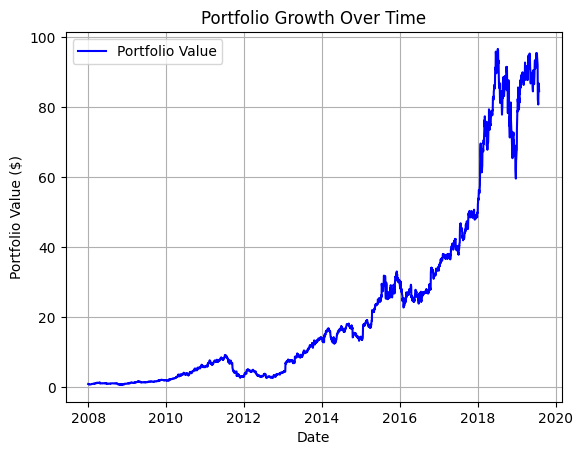

In [14]:
portfolio_returns(data_clean, top_3_stocks, [0.8, 0.1, 0.1])

#### Trying different weights

In [15]:
# Experimenting to see how different weights affect the portfolio value over time
weights_list = [
    [0.33, 0.33, 0.34],  
    [0.5, 0.3, 0.2],      
    [0.2, 0.5, 0.3],
    [0.8, 0.1, 0.1],
    [0.005,0.99, 0.005]
]

In [16]:
results = {}

4948.42% gain
6527.25% gain
3836.27% gain
8356.09% gain
2139.42% gain


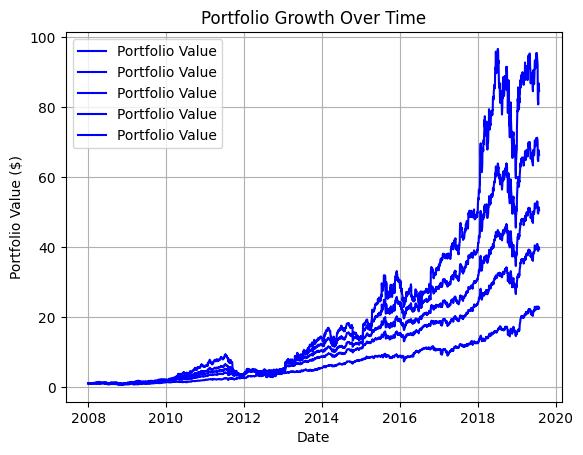

In [17]:
for weights in weights_list:
    returns = portfolio_returns(data_clean, top_3_stocks, weights)

Can see highest return of 8356% come from original weight allocation; 80% to Netflix, 10% each to Ross and TDG

#### Optimisation algorithm SLSQP (Experimenting to see how different methods work)

In [30]:
# A function that just calculates the portfolio growth over the period for a list of stocks and weights
# Output is negative of the cumulative returns as a minimisation optimisation is attempted below
from scipy.optimize import minimize
def portfolio_growth(weights, data, stock_list):
    """Objective function: Maximizing final portfolio value."""
    weights = np.array(weights) / np.sum(weights)  
    
    returns = data[stock_list].pct_change(periods=1).dropna()
    portfolio_ret = returns.dot(weights)
    cumulative_returns = (1 + portfolio_ret).cumprod()

    return -cumulative_returns.iloc[-1]

In [31]:
# A function that applies SLSQP optimisation that attempts to maximise the returns given a data frame and a list of stocks
def optimize_relative_weights(data, stock_list):
    """Finds optimal relative weight allocation."""
    num_stocks = len(stock_list)

    # Initialises with an equally weighted portfolio
    init_weights = np.ones(num_stocks) / num_stocks

    # Ensures each weight is between 0 and 1
    bounds = [(0, 1)] * num_stocks  

    # Ensures all weights sum to 1
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    # Applies the SLSQP algorithm to the portfolio_growth function defined above
    result = minimize(portfolio_growth, init_weights, args=(data, stock_list),
                      method='SLSQP', bounds=bounds, constraints=constraints)
    
    optimal_weights = result.x / np.sum(result.x)  
    max_growth = -result.fun

    return optimal_weights.round(4), max_growth

In [32]:
# Optimises weights for the 3 stocks selected earlier
optimal_weights, max_growth = optimize_relative_weights(data_clean, top_3_stocks)

In [33]:
print(f"Optimal weight allocation: {optimal_weights}")
print(f"Maximum percentage gain: {(100*(max_growth - 1)).round(3)}%")

Optimal weight allocation: [0.9018 0.0982 0.    ]
Maximum percentage gain: 8613.69%


The weight allocation from SLSQP explains why the first 80-10-10 allocation worked so well. Netflix is likely to be a top-performing stock hence the algorithm recommends we allocate 90% of our money to Netflix and just under 10% to TDG, but surprisingly none to Ross

#### Optimisation algorithm Min-Variance

In [34]:
def min_variance_portfolio(data, stock_list):
    """Finds the minimum variance portfolio allocation."""
    returns = data[stock_list].pct_change().dropna()

    # Calculates covariance matrix to measure how stocks move together
    cov_matrix = returns.cov()  

    
    num_stocks = len(stock_list)
    init_weights = np.ones(num_stocks) / num_stocks  

    # Defines the objective function to be minimised
    def portfolio_variance(weights):
        return weights.T @ cov_matrix @ weights

    # Ensures all weights sum to 1
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    # Ensures each weight is between 0 and 1
    bounds = [(0, 1)] * num_stocks  

    # Again applies the SLSQP method to minimise objective function
    result = minimize(portfolio_variance, init_weights, method='SLSQP',
                      bounds=bounds, constraints=constraints)

    optimal_weights = result.x / np.sum(result.x)  
    min_variance = result.fun

    return optimal_weights.round(4), min_variance

In [35]:
optimal_weights, min_variance = min_variance_portfolio(data_clean, top_3_stocks)

In [36]:
print(f"Optimal min-variance weight allocation: {optimal_weights}")
print(f"Minimum variance: {min_variance:.6f}")

Optimal min-variance weight allocation: [0.3333 0.3333 0.3333]
Minimum variance: 0.000287


4983.40% gain


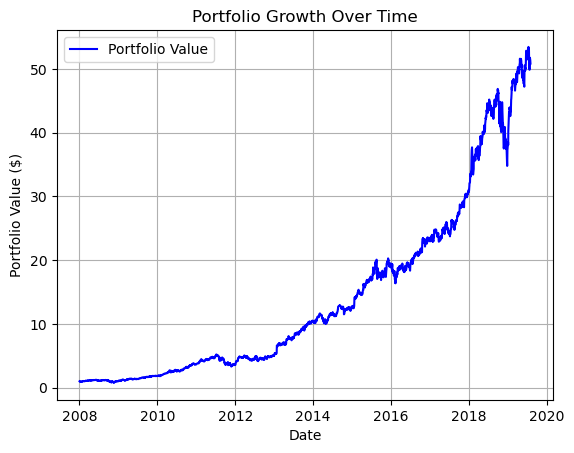

In [37]:
portfolio_returns(data_clean, top_3_stocks, optimal_weights)

AFTER USING 2 OPTIMISATION ALGORITHMS:
Using SLSQP without min-variance gives better returns (8613% vs 4983%) but may be more riskier. Min-variance ensures we have the least risk possible

### **Absolute Weights**

In [38]:
def calculate_portfolio_value(data, stocks, shares):
    """
    Calculates and plots the total dollar value growth of a portfolio over time
    based on a fixed number of shares held for each stock.
    """

    # Finds first available price for each stock
    initial_prices = {}
    for stock in stocks:
        first_valid_index = data[stock].first_valid_index()  
        initial_prices[stock] = data.loc[first_valid_index, stock]  

    # Calculates total starting cash allocation (Shares * Starting price)
    initial_investment = sum([shares[i] * initial_prices[stock] for i, stock in enumerate(stocks)])
    print(f"Initial investment: ${initial_investment:.2f}")
    
    daily_returns = data[stocks].pct_change(periods = 1)

    # The block below calculates portfolio growth, similar to the portfolio_growth function
    shares = np.array(shares)
    portfolio_returns = daily_returns @ shares  

    portfolio_value = (1 + portfolio_returns).cumprod() * initial_investment

    final_value = portfolio_value.iloc[-1]
    print(f"Final value: ${final_value:.2f}")

    print(f"Percentage growth: {((final_value/initial_investment)*100)-100:.2f}%")

    # Plots portfolio value over time
    plt.plot(portfolio_value, label="Portfolio Value", color='blue')
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value ($)")
    plt.title("Portfolio Growth Over Time")
    plt.legend()
    plt.grid(True)

In [39]:
shares = [1, 2, 1]

Initial investment: $53.73
Final value: $1826810.52
Percentage growth: 3400084.86%


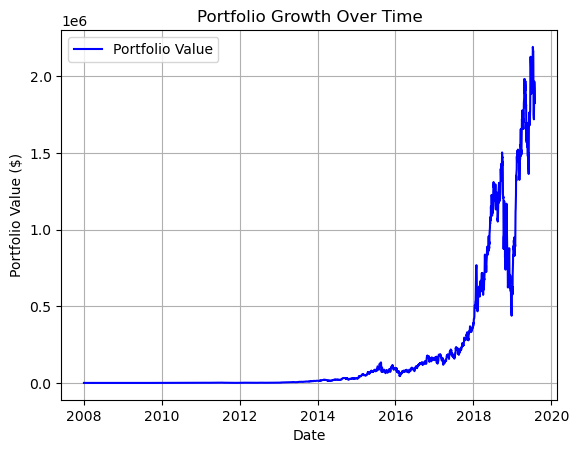

In [40]:
# Applies the function defined above to the top 3 stocks identified
calculate_portfolio_value(data_clean, top_3_stocks, shares)

In [41]:
from scipy.optimize import differential_evolution

In [42]:
def final_port_value_absolute(data, stocks, weights):
    """
    Calculates the initial investment and final portfolio value
    """
    # Finds first available price for each stock 
    initial_prices = {stock: data.loc[data[stock].first_valid_index(), stock] for stock in stocks}

    # Calculates total starting cash allocation (Shares * Starting price)
    initial_investment = sum(weights[i] * initial_prices[stock] for i, stock in enumerate(stocks))

    # The block below calculates portfolio growth, similar to the portfolio_growth function
    daily_returns = data[stocks].pct_change()
    
    weights = np.array(weights)  
    portfolio_returns = daily_returns @ weights  

    portfolio_value = (1 + portfolio_returns).cumprod() * initial_investment
    final_value = portfolio_value.iloc[-1]

    return initial_investment, final_value

In [43]:
def objective(weights, data, stocks):
    """Objective function: Maximizing percentage growth."""
    weights = np.round(weights).astype(int)  
    
    # Runs the portfolio value calculator with the integer share counts
    initial_investment, final_value = final_port_value_absolute(data, stocks, weights)

    # Calculate total return/percentage growth
    percentage_growth = ((final_value - initial_investment) / initial_investment) * 100
    return -percentage_growth

In [44]:
def optimize_absolute_shares(data, stocks):
    """Finds the best absolute share allocation for max portfolio growth."""
    # Ensuring each stock has between 1 and 10 shares
    bounds = [(1, 10)] * len(stocks)  

    # Optimising the objective function using differential_evolution (works well with integer/discrete problems)
    result = differential_evolution(objective, bounds, args=(data, stocks), strategy='best1bin', maxiter=100, tol=1e-6)

    # If any decimal shares, they are rounded to whole numbers
    optimal_shares = np.round(result.x).astype(int)
    max_growth = -result.fun  
    return optimal_shares, max_growth

In [45]:
best_shares, max_growth = optimize_absolute_shares(data_clean, top_3_stocks)
print(f"Best share allocation: {best_shares}, Maximum growth: {max_growth:.2f}%")

Best share allocation: [1 2 2], Maximum growth: 7907746.22%


Initial investment: $59.44
Final value: $4700313.08
Percentage growth: 7907746.22%


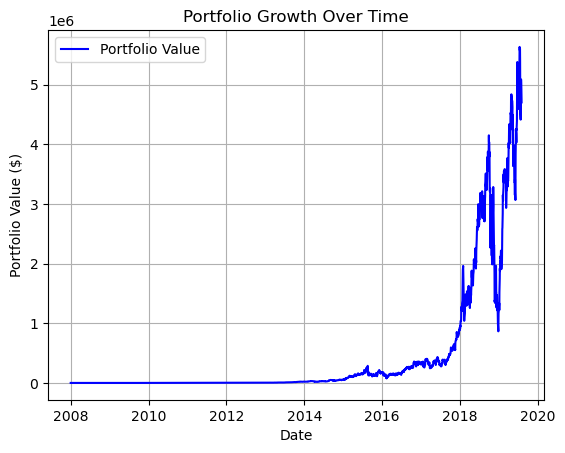

In [46]:
calculate_portfolio_value(data_clean, top_3_stocks, best_shares)

Best allocation is 1 stock of Netflix, 2 stocks of TDG and 2 stocks of Ross which gives a final value of over 4.7 million USD with an initial investment of 59.44 USD. Note how this contradicts with relative weights, which gave more weightage to Netflix and not much importance to Ross stores.

## Simulating through stocks and weights

In [14]:
def simulate_portfolios(data = data_clean, top_100_tickers = [ticker for ticker, _ in sharpe_sorted[:100]], n_simulations=20000, min_stocks=5, max_stocks=20):
    """
    A Monte Carlo simulation to find the best performing portfolios using the cleaned dataset and the top 100 stocks based on Sharpe ratio.
    Allowing each simulation to choose between 5 and 20 stocks
    """
    daily_returns = data.pct_change().dropna()
    best_portfolios = []

    # Runs the simulation n_simulation times
    for _ in range(n_simulations):
        # Randomly chooses how many stocks to include
        n_stocks = np.random.randint(min_stocks, max_stocks + 1)

        # Randomly picks that number of unique stocks out of the top 100 stocks (no duplicates)
        selected_stocks = np.random.choice(top_100_tickers, size=n_stocks, replace=False)

        # Generates random weights between 0 and 1 and normalises them to ensure they sum to 1
        weights = np.random.random(n_stocks)
        weights /= np.sum(weights)  
        
        # Calculates total return over the time frame
        portfolio_returns = daily_returns[selected_stocks].dot(weights)
        cumulative_return = (1 + portfolio_returns).prod() - 1

        # Calculates the annualised Sharpe ratio
        sharpe = (portfolio_returns.mean() / portfolio_returns.std()) * np.sqrt(252)

        # Stores the selected stocks, the allocated weight of each one, cumulative returns and annualised sharpe ratio in a dictionary
        best_portfolios.append({
            'stocks': selected_stocks,
            'weights': weights,
            'cumulative_return': cumulative_return,
            'sharpe': sharpe
        })
    # Sorts the dictionary of simulated portfolios by Sharpe ratio in descending order
    best_portfolios.sort(key=lambda x: x['sharpe'], reverse=True)

    return best_portfolios[:5]

In [15]:
top_portfolios = simulate_portfolios()
top_portfolios

[{'stocks': array(['MCD US Equity', 'RHT US Equity', 'IAC US Equity', 'NI US Equity',
         'ILMN US Equity', 'STZ US Equity', 'ABMD US Equity',
         'IDXX US Equity', 'TDG US Equity', 'CHD US Equity',
         'AON US Equity', 'CMS US Equity', 'AGN US Equity', 'EW US Equity',
         'NFLX US Equity', 'MU US Equity', 'AZO US Equity', 'MMC US Equity',
         'EXR US Equity'], dtype='<U15'),
  'weights': array([0.04059533, 0.05421536, 0.05596427, 0.07551565, 0.03254381,
         0.063668  , 0.07397681, 0.01691946, 0.07404261, 0.02102864,
         0.00985331, 0.02882026, 0.05904147, 0.06766142, 0.07774897,
         0.00283504, 0.11273752, 0.0667236 , 0.06610848]),
  'cumulative_return': 16.838556810536648,
  'sharpe': 1.390724161649743},
 {'stocks': array(['TMO US Equity', 'EL US Equity', 'NFLX US Equity',
         'REGN US Equity', 'EW US Equity', 'TSN US Equity', 'AJG US Equity',
         'ABT US Equity', 'HD US Equity', 'BLL US Equity', 'MNST US Equity',
         'TDG US Equ

Can see the returns of even the top simulated portfolios are very modest compared to the optimisation algorithms of both, relative and absolute weights. Our top portfolio has a Sharpe ratio of 1.39, chooses 19 stocks but does not have the highest cumulative returns. The 4th best portfolio gives the highest returns of 25% and also contains 11 stocks compared to 19.

# Dynamic Weights part 1

In [16]:
def dynamic_rebalance(portfolio_stocks, initial_weights, data = data_clean, rebalance_period='6M', risk_free_rate=0.0258, initial_investment = 1, transaction_rate = 0.002):
    """
    Simulates a dynamically weighted allocation strategy that periodically rebalances 
    portfolio weights based on historical stock Sharpe ratios, incorporating 
    transaction costs.
    """
    returns = data[portfolio_stocks].pct_change().dropna()

    # Initialises a Series to track total value over time and current asset weights
    portfolio_value = pd.Series(initial_investment, index=returns.index)
    weights = pd.Series(initial_weights, index=portfolio_stocks)
    prev_weights = weights.copy()  # Track for turnover cost

    prev_date = returns.index[0]
    current_value = initial_investment

    # Generates specific calendar milestones to trigger rebalancing
    rebal_dates = pd.date_range(start=returns.index[0], end=returns.index[-1], freq=rebalance_period)

    #print("Initial Portfolio Weights:", weights)
    #print("Initial Portfolio Value: $", current_value)

    # Iterates through each rebalancing date
    for date in rebal_dates[1:]:
        # If rebalance date falls on a non-trading day, rolls back to last available trading day
        if date not in returns.index:
            date = returns[returns.index <= date].index[-1]

        # Calculates cumulative returns for the current period
        period_returns = returns.loc[prev_date:date]
        weighted_returns = period_returns.dot(weights)
        current_value *= (1 + weighted_returns).prod()

        # Store portfolio value over this period
        portfolio_value.loc[prev_date:date] = current_value

        #print(f"Period {prev_date.date()} to {date.date()} | Value: ${current_value:.2f}")

        # Compute annualised Sharpe ratios for each stock over the historical period
        excess_returns = period_returns - (risk_free_rate / 261)
        avg_excess_return = excess_returns.mean() * 261
        annual_volatility = excess_returns.std() * np.sqrt(261)
        
        sharpe_ratios = avg_excess_return / annual_volatility

        # Any negative Sharpe ratios are labelled as 0
        sharpe_ratios = np.clip(sharpe_ratios, 0, None)

        # Generates new asset weights proportionally based on their relative Sharpe ratios
        if sharpe_ratios.sum() == 0:
            new_weights = pd.Series(1.0 / len(sharpe_ratios), index=sharpe_ratios.index)
        else:
            new_weights = sharpe_ratios / sharpe_ratios.sum()

        # Transaction Cost 
        turnover = np.abs(new_weights - prev_weights).sum()

        # Applies the fee percentage to the total dollar value moved
        cost = turnover * transaction_rate * current_value
        current_value -= cost  # Deduct from value
        #print(f"Transaction Cost: ${cost:.2f} | Turnover: {turnover:.4f}")

        # Update weights and prev_date
        weights = new_weights
        prev_weights = weights.copy()
        prev_date = date

    return portfolio_value

In [14]:
portfolio_stocks = ['NFLX US Equity', 'GPN US Equity', 'AJG US Equity',
         'ULTA US Equity', 'DTE US Equity']
initial_weights = [0.63828136, 0.01676285, 0.01720897, 0.25760015, 0.07014668]

In [15]:
dynamic_port = dynamic_rebalance(portfolio_stocks, initial_weights)
dynamic_port

Date
2008-01-02     0.990110
2008-01-03     0.990110
2008-01-04     0.990110
2008-01-07     0.990110
2008-01-08     0.990110
                ...    
2019-07-25    29.330307
2019-07-26    29.330307
2019-07-29    29.330307
2019-07-30    29.330307
2019-07-31    29.330307
Length: 3021, dtype: float64

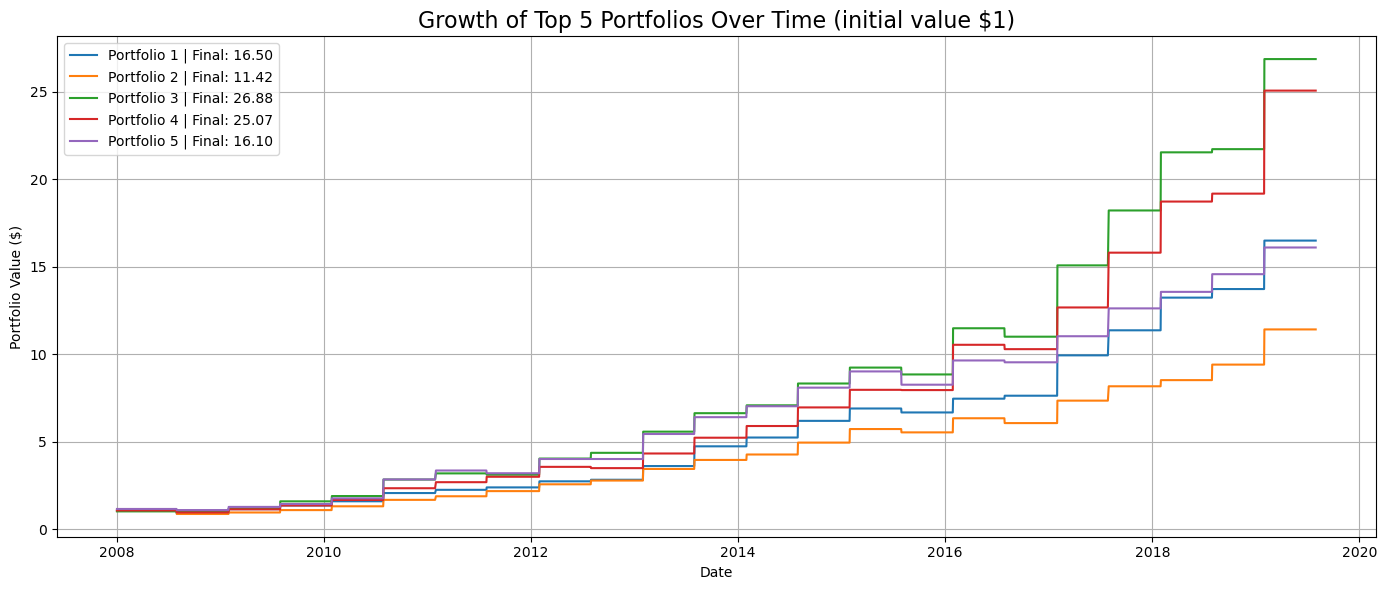

In [17]:
plt.figure(figsize=(14, 6))

# Applying dynamic weighting to the top 5 portfolios selected from simulation
for i, portfolio in enumerate(top_portfolios, start=1):
    #print(top_portfolios[0])
    stocks = portfolio['stocks']
    weights = portfolio['weights']
    
    port_val = dynamic_rebalance(stocks, weights, data=data_clean)
    
    plt.plot(port_val.index, port_val.values, label=f"Portfolio {i} | Final: {port_val.iloc[-1]:.2f}")

# Plots all 5 portfolios and their growth over each rebalancing period, also printing the final cumulative return
plt.title("Growth of Top 5 Portfolios Over Time (initial value $1)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Overall, the dynamic weighting performed similarly to simulation, generating comparable returns. The exceptions are Portfolios 2 where dynamic weighting underperformed and Portfolio 3 where the dynamic weighting performed better than simulation.

### Comparing Static vs Dynamic

In [13]:
# Extracts the assets and their weights from the top portfolio generated by Monte Carlo
best_portfolio = top_portfolios[0]
stocks = best_portfolio['stocks']
weights = best_portfolio['weights']

# Computes returns for the static weighting portfolio
returns = data_clean[stocks].pct_change().dropna()
static_returns = returns.dot(weights)
static_value = (1 + static_returns).cumprod() -1

# Runs the dynamic weighting strategy on the same stocks and weights
dynamic_value = dynamic_rebalance(stocks, weights, data=data_clean)

# Aligns timelines of both portfolios to allow graphical comparison
common_index = static_value.index.intersection(dynamic_value.index)
static_value = static_value.loc[common_index]
dynamic_value = dynamic_value.loc[common_index]

# Plots the static and dynamic portfolio performances over time
plt.figure(figsize=(12, 6))
plt.plot(static_value, label='Static Portfolio', linewidth=2, color='tab:blue')
plt.plot(dynamic_value, label='Dynamic Portfolio', linewidth=2, linestyle='--', color='tab:orange')
plt.title("Static vs Dynamic Portfolio Growth", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

AttributeError: 'numpy.float64' object has no attribute 'index'

Issue with this whole strategy is look-ahead bias, training and testing periods must be established to properly evaluate any method (static or dynamic)

# Dynamic weights part 2 (final version and more accurate)

In [ ]:
# Splitting the data into roughly 80% training and 20% testing sets
train_data = data_clean.loc['2008-01-01':'2016-12-31']
test_data = data_clean.loc['2017-01-01':'2019-07-31']

In [28]:
from scipy.optimize import minimize
daily_returns = data_clean.pct_change().dropna() 

# Defines rolling window parameters
lookback_days = 252  
start_test = '2017-01-31'
end_test = '2019-07-31'   
risk_free_rate = 0.0258 / 252
rebalance_freq = 35
transaction_cost_rate = 0.01

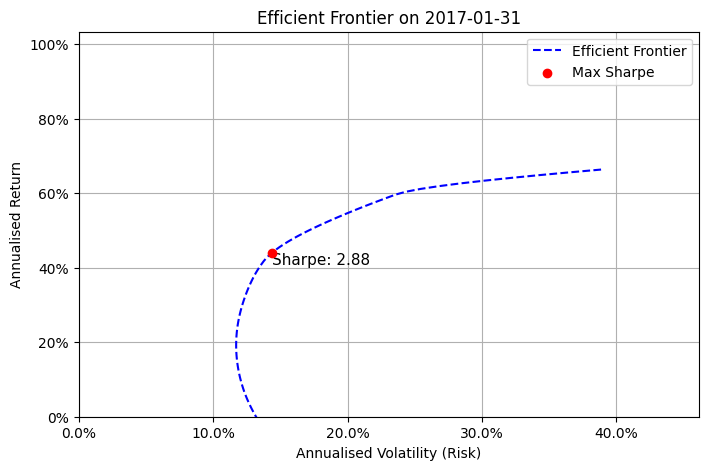

In [62]:
# Slices the time series index for the test window and selects rebalancing dates based on frequency
trading_days = daily_returns.loc[start_test:end_test].index
rebalance_dates = trading_days[::rebalance_freq]

# Initialises lists to track portfolio history metrics
weights_history = []
portfolio_returns = []
transaction_costs = []
frontiers = []

# Sorts stocks by training set Sharpe ratio and isolate the top 10 stocks
sharpe_sorted = calculate_sharpe(train_data)
top_stocks = [stock for stock, _ in sharpe_sorted[:10]]
n_assets = len(top_stocks)

# Initialises with equally weighted assets
prev_weights = np.ones(n_assets) / n_assets 

# Begins rolling window execution loop across all rebalancing timestamps
for date in rebalance_dates:
    # Sets up the lookback training boundaries relative to the current rebalance day
    train_end = date - pd.Timedelta(days=1)
    train_start = train_end - pd.Timedelta(days=lookback_days)
    train_window = daily_returns.loc[train_start:train_end, top_stocks]

    # Calculates daily sample mean returns and covariance for the window
    mu = train_window.mean().values
    cov_matrix = train_window.cov().values

    # Annualises mean returns and covariance (earlier calculations used 261 trading days which is wrong!)
    mu_annual = mu * 252
    cov_annual = cov_matrix * 252

    ## EFFICIENT FRONTIERS COMING IN HERE
    # Generates 100 target returns linearly spaced between the lowest and highest annualised stock returns
    target_returns = np.linspace(min(mu_annual), max(mu_annual), 100)
    efficient_risks = []
    efficient_returns = []
    
    bounds = [(0.0, 1.0) for _ in range(n_assets)]
    initial_w = np.ones(n_assets) / n_assets

    # Traces out the frontier boundary curve by minimising volatility at every target return tier
    for target in target_returns:
        # Ensures weights sum to 1 and portfolio returns match the specific target
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, target=target: np.dot(w, mu_annual) - target}
        ]
        # Short function to calculate annualised portfolio volatility
        def portfolio_volatility(w):
            return np.sqrt(np.dot(w.T, np.dot(cov_annual, w)))

        # Optimises asset allocations to identify the absolute lowest risk point for the target return
        result = minimize(portfolio_volatility, initial_w, method='SLSQP',
                          bounds=bounds, constraints=constraints)

        # Only appends to the list if the solver found a valid point
        if result.success:
            efficient_risks.append(result.fun)
            efficient_returns.append(target)
            
    # Maps raw list data structures into structured arrays for vector calculations
    efficient_risks = np.array(efficient_risks)
    efficient_returns = np.array(efficient_returns)

    # Calculates annualised Sharpe ratios and locates the point with the maximum ratio
    sharpe_ratios = (efficient_returns - risk_free_rate * 252) / efficient_risks
    max_sharpe_idx = np.argmax(sharpe_ratios)

    # Logs the complete coordinates, the max Sharpe coordinate, and the date timestamp
    frontiers.append((
        efficient_risks,
        efficient_returns,
        (efficient_risks[max_sharpe_idx], efficient_returns[max_sharpe_idx]),
        date.strftime('%Y-%m-%d')
    ))

    # Efficient Frontier - Max Sharpe Portfolio
    # Defines optimisation function using daily parameters (not annualised)
    def neg_sharpe(w):
        port_return = np.dot(mu, w)
        port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
        sharpe = (port_return - risk_free_rate) / port_vol
        return -sharpe

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = [(0.0, 1.0)] * n_assets
    initial_w = np.ones(n_assets) / n_assets

    result = minimize(neg_sharpe, initial_w, method='SLSQP',
                      bounds=bounds, constraints=constraints)

    # Ensures weight allocations are between 5% and 35%
    weights = np.clip(result.x, 0.05, 0.35)
    weights = weights / weights.sum()  

    # Save weights
    weights_series = pd.Series(weights, index=top_stocks, name=date)
    weights_history.append(weights_series)

    # Transaction cost
    turnover = np.sum(np.abs(weights - prev_weights))
    transaction_cost = transaction_cost_rate * turnover
    transaction_costs.append(transaction_cost)

    prev_weights = weights.copy()

    # Compute returns until next rebalance
    next_idx = rebalance_dates.get_loc(date) + 1
    if next_idx < len(rebalance_dates):
        next_date = rebalance_dates[next_idx]
        period_returns = daily_returns.loc[date:next_date, top_stocks]
        daily_portfolio_returns = period_returns.dot(weights)
        gross_return = (1 + daily_portfolio_returns).prod() - 1
        net_return = gross_return - transaction_cost
        portfolio_returns.append(net_return)

# Results
# Constructs a series tracking period-by-period forward returns indexed to rebalance times
portfolio_returns_series = pd.Series(portfolio_returns, index=rebalance_dates[:len(portfolio_returns)])
cumulative_return = (1 + portfolio_returns_series).cumprod()

# Scales the time-series Sharpe ratio using a factor adjusted to the rebalancing period
annualization_factor = np.sqrt(252 / rebalance_freq)
sharpe_ratio = portfolio_returns_series.mean() / portfolio_returns_series.std() * annualization_factor

fig, ax = plt.subplots(figsize=(8, 5))

all_risks = np.concatenate([risk for risk, *_ in frontiers])
all_returns = np.concatenate([ret for _, ret, *_ in frontiers])

x_min, x_max = 0, all_risks.max() * 1.05  # Slight buffer for aesthetics
y_min, y_max = 0, all_returns.max() * 1.05

# Shows the efficiency frontier for each rebalancing period as an animation, highlighting the point with max Sharpe ratio
def update(frame):
    ax.clear()
    risks, rets, (max_sharpe_x, max_sharpe_y), date_str = frontiers[frame]
    
    ax.plot(risks, rets, linestyle='--', color='blue', label='Efficient Frontier')
    ax.scatter(max_sharpe_x, max_sharpe_y, color='red', label='Max Sharpe', zorder=5)
    ax.text(max_sharpe_x, max_sharpe_y, f"Sharpe: {(max_sharpe_y - risk_free_rate*252)/max_sharpe_x:.2f}", fontsize=11,
            verticalalignment='top', horizontalalignment='left', color='black')
    ax.set_title(f"Efficient Frontier on {date_str}")
    ax.set_xlabel("Annualised Volatility (Risk)")
    ax.set_ylabel("Annualised Return")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend()
    ax.grid(True)

ani = FuncAnimation(fig, update, frames=len(frontiers), interval=1000)
ani.save("efficient_frontier.gif", writer=PillowWriter(fps=1))

In [63]:
cumulative_return

Date
2017-01-31    1.013246
2017-03-21    1.007244
2017-05-09    0.977542
2017-06-27    0.964613
2017-08-15    0.966416
2017-10-03    0.977412
2017-11-21    1.066770
2018-01-09    1.100871
2018-02-27    1.116717
2018-04-17    1.188937
2018-06-05    1.227509
2018-07-24    1.268361
2018-09-11    1.142860
2018-10-30    1.081723
2018-12-18    1.165259
2019-02-05    1.250743
2019-03-26    1.252836
2019-05-14    1.370442
dtype: float64

In [61]:
total_cost = np.sum(transaction_costs)
print(f"Total Transaction Costs: {total_cost:.4f}")

Total Transaction Costs: 0.0773


If the point with maximum Sharpe ratio is chosen at every period, the portfolio would see an expected 37% growth with transaction costs of $0.0773

## Efficient frontiers

**All code here was about exploring how to plot efficiency frontiers. It was an experiment which was properly implemented in Dynamic Weights Part 2**

In [45]:
train_window = daily_returns.loc['2008-01-01':'2016-12-31', top_stocks]
mu = train_window.mean().values * 252  
cov_matrix = train_window.cov().values * 252  

target_returns = np.linspace(min(mu), max(mu), 100)
efficient_risks = []
efficient_returns = []

bounds = [(0.0, 1.0) for _ in range(n_assets)]
initial_w = np.ones(n_assets) / n_assets

for target in target_returns:
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target}
    ]

    def portfolio_volatility(w):
        return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

    result = minimize(portfolio_volatility, initial_w, method='SLSQP', bounds=bounds, constraints=constraints)
    if result.success:
        efficient_risks.append(result.fun)
        efficient_returns.append(target)

Max Sharpe Ratio: 1.492
Return: 32.20%, Risk: 21.57%


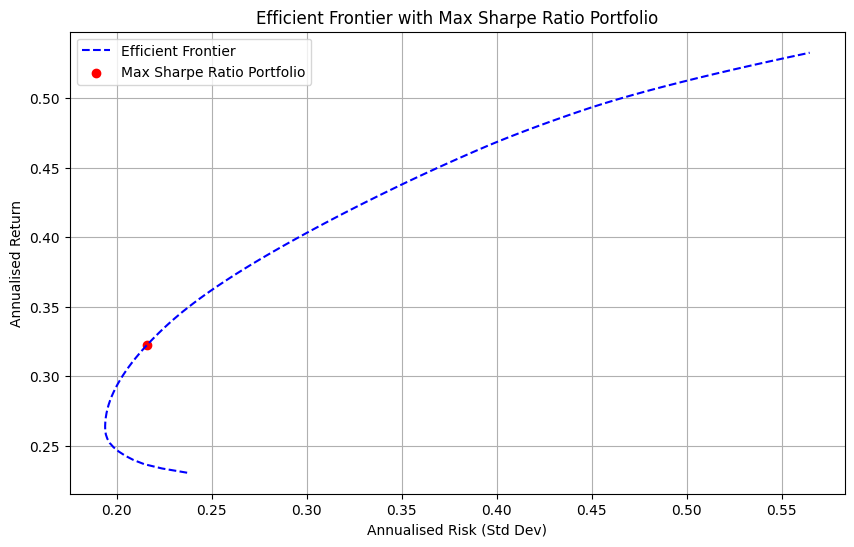

In [46]:
returns = np.array(efficient_returns)
risks = np.array(efficient_risks)

sharpe_ratios = (returns - risk_free_rate) / risks
max_sharpe_idx = np.argmax(sharpe_ratios)

print(f"Max Sharpe Ratio: {sharpe_ratios[max_sharpe_idx]:.3f}")
print(f"Return: {returns[max_sharpe_idx]:.2%}, Risk: {risks[max_sharpe_idx]:.2%}")

plt.figure(figsize=(10, 6))
plt.plot(risks, returns, 'b--', label='Efficient Frontier')
plt.scatter(risks[max_sharpe_idx], returns[max_sharpe_idx], color='red', label='Max Sharpe Ratio Portfolio')
plt.xlabel('Annualised Risk (Std Dev)')
plt.ylabel('Annualised Return')
plt.title('Efficient Frontier with Max Sharpe Ratio Portfolio')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
portfolio_returns_series = pd.Series(portfolio_returns, index=rebalance_dates[:len(portfolio_returns)])
cumulative_return = (1 + portfolio_returns_series).cumprod()

annualization_factor = np.sqrt(252 / rebalance_freq) 
sharpe_ratio = portfolio_returns_series.mean() / portfolio_returns_series.std() * annualization_factor

# print(f"Sharpe Ratio: {sharpe_ratio:.3f}")
# print(f"Final return: {cumulative_return[-1].round(3)}")
# cumulative_return.plot(title="Mean-Variance Portfolio: Rebalance period 35 days")
# plt.ylabel('Cumulative Return')
# plt.show()